# Perguntas de Negócio

## Crescimento do Catálogo

1. Como o catálogo da Netflix cresceu ao longo do tempo?
2. Houve períodos de aceleração ou desaceleração na adição de conteúdos?
3. A Netflix adiciona mais filmes ou mais séries atualmente?

## Estratégia de Conteúdo

4. Quais gêneros recebem maior investimento?
5. O catálogo é composto majoritariamente por conteúdos recentes ou antigos?
6. Quanto tempo, em média, leva para um conteúdo entrar na Netflix após o lançamento?

## Diversidade Geográfica

7. Quais países dominam o catálogo da Netflix?
8. Existe diversificação internacional ao longo dos anos?

## Talentos e Parcerias

9. Quais diretores possuem mais obras disponíveis na Netflix?
10. Quais atores aparecem com maior frequência nos títulos disponíveis?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
#!pip freeze > requirements.txt

netflix = pd.read_csv('../data/processed/netflix.csv')
netflix_directors = pd.read_csv('../data/processed/netflix_directors.csv')
netflix_cast = pd.read_csv('../data/processed/netflix_cast.csv')

In [35]:
netflix.head()

,type,title,description,director,n_directors,cast,n_cast_members,country,n_countries,main_country,continent,language,release_year,release_decade,date_added,year_added,delay_added,rating,rating_group,duration,duration_category,listed_in,n_genres,genre
0,Movie,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",Kirsten Johnson,1,Not Informed,0,United States,1,United States,North America,English,2020,2020,2021-09-25,2021.0,1.0,PG-13,Teen,90,Feature Film,Documentaries,1,Documentary
1,TV Show,Blood & Water,"After crossing paths at a party, a Cape Town t...",Not Informed,0,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",19,South Africa,1,South Africa,Africa,English,2021,2020,2021-09-24,2021.0,0.0,TV-MA,Adult,2,Short Series,"International TV Shows, TV Dramas, TV Mysteries",3,International
2,TV Show,Ganglands,To protect his family from a powerful drug lor...,Julien Leclercq,1,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",9,Unknown,0,Unknown,Unknown,Unknown,2021,2020,2021-09-24,2021.0,0.0,TV-MA,Adult,1,Limited Series,"Crime TV Shows, International TV Shows, TV Act...",3,Crime
3,TV Show,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",Not Informed,0,Not Informed,0,Unknown,0,Unknown,Unknown,Unknown,2021,2020,2021-09-24,2021.0,0.0,TV-MA,Adult,1,Limited Series,"Docuseries, Reality TV",2,Documentary
4,TV Show,Kota Factory,In a city of coaching centers known to train I...,Not Informed,0,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",8,India,1,India,Asia,Hindi,2021,2020,2021-09-24,2021.0,0.0,TV-MA,Adult,2,Short Series,"International TV Shows, Romantic TV Shows, TV ...",3,International


In [36]:
netflix.date_added.min()

'2008-01-01'

In [37]:
netflix.date_added.max()

'2021-09-25'

In [38]:
movies = netflix.loc[netflix['type'] == 'Movie'].copy()
tv_shows = netflix.loc[netflix['type'] == 'TV Show'].copy()

In [39]:
movies.delay_added.describe()

count    6131.000000
mean        5.728103
std         9.742423
min         0.000000
25%         0.000000
50%         2.000000
75%         7.000000
max        75.000000
Name: delay_added, dtype: float64

<Axes: xlabel='delay_added'>

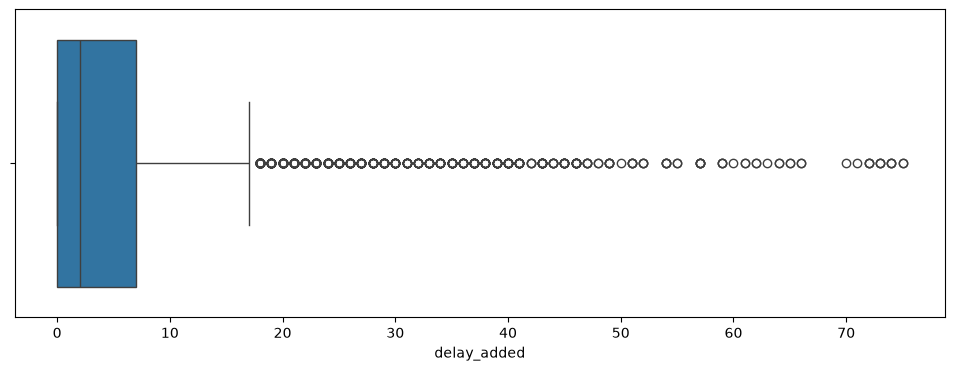

In [ ]:
plt.figure(figsize=(12,4))
sns.boxplot(x=movies['delay_added'])

In [ ]:
movies['date_added'] = pd.to_datetime(
    movies['date_added'],
    errors='coerce'
)

weekly_movies = (
    movies
    .dropna(subset=['date_added'])
    .set_index('date_added')
    .resample('W-MON')
    .size()
    .reset_index(name='count')
)

fig = px.bar(
    weekly_movies,
    x='date_added',
    y='count',
    title='Quantidade de filmes adicionados à Netflix por semana',
    labels={
        'date_added': 'Semana',
        'count': 'Quantidade de filmes'
    }
)

fig.update_layout(
    xaxis_title='Semana',
    yaxis_title='Quantidade de filmes',
    xaxis=dict(rangeslider=dict(visible=True)),
    hovermode='x unified'
)

fig.show()

ModuleNotFoundError: No module named 'plotly'

In [48]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 14.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


In [42]:
tv_shows.delay_added.describe()

count    2666.000000
mean        2.303826
std         5.317390
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        93.000000
Name: delay_added, dtype: float64

<Axes: xlabel='delay_added'>

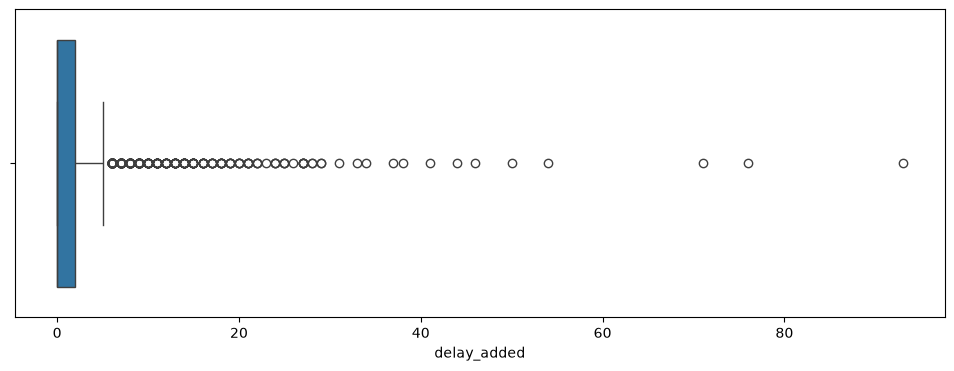

In [43]:
plt.figure(figsize=(12,4))
sns.boxplot(x=tv_shows['delay_added'])